# Daily Product Demand Forecasting

**Portfolio version** of a graduate data science project by Wendy Eidson.

The original project used private POS transaction data from a small Denver coffee shop. This public notebook uses a **synthetic sample dataset** so the workflow can be shared safely and reproduced end to end.

## Business goal

Forecast next-day menu-item demand to support production and inventory planning. The workflow focuses on both **data quality** and **forecasting quality**, because unreliable product names or transaction records can degrade the modeling table before a model is ever trained.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.forecasting import (
    FEATURES, clean_transactions, build_model_table,
    train_and_evaluate, build_next_day_feature_row
)

DATA_PATH = ROOT / "data" / "sample_pos_transactions.csv"
raw = pd.read_csv(DATA_PATH)
print(f"Synthetic transaction rows: {len(raw):,}")
raw.head()

Synthetic transaction rows: 45,031


,Order #,Sent Date,Menu Item,Menu Group,Menu,Sales Category,Net Price,Qty,Void?,source_file,sent_date,sent_time,year,month,month_name,hour_of_day,day_of_week_num,day_of_week,is_weekend
0,100000,1/1/24 2:12 PM,Cheese Bread,Breads,Main Menu,Food,4.50,3.0,False,synthetic_2024_01.csv,2024-01-01,14:12:00,2024,1,January,14,0,Monday,False
1,100001,1/1/24 10:45 AM,Cheese Bread,Breads,Main Menu,Food,4.73,3.0,False,synthetic_2024_01.csv,2024-01-01,10:45:00,2024,1,January,10,0,Monday,False
2,100002,1/1/24 2:10 PM,Cheese Bread,Breads,Main Menu,Food,4.73,2.0,False,synthetic_2024_01.csv,2024-01-01,14:10:00,2024,1,January,14,0,Monday,False
3,100003,1/1/24 12:49 PM,Cheese Bread,Breads,Main Menu,Food,4.50,2.0,False,synthetic_2024_01.csv,2024-01-01,12:49:00,2024,1,January,12,0,Monday,False
4,100004,1/1/24 8:51 AM,Cheese Bread,Breads,Main Menu,Food,4.27,2.0,False,synthetic_2024_01.csv,2024-01-01,08:51:00,2024,1,January,8,0,Monday,False


## 1. Data quality and standardization

The cleaning layer removes voided transactions, parses timestamps, repairs text encoding, normalizes product names, and uses fuzzy token matching to consolidate near-duplicate menu-item labels.

In [2]:
clean = clean_transactions(raw)
print(f"Rows after removing voids/invalid dates: {len(clean):,}")
print(f"Raw menu item variants: {raw['Menu Item'].nunique()}")
print(f"Standardized menu items: {clean['Menu Item Final'].nunique()}")
clean[['Sent Date','Menu Item','Menu Item Final','Qty','Net Price']].head()

Rows after removing voids/invalid dates: 44,753
Raw menu item variants: 12
Standardized menu items: 12


,Sent Date,Menu Item,Menu Item Final,Qty,Net Price
0,2024-01-01 14:12:00,Cheese Bread,Cheese Bread,3.0,4.50
1,2024-01-01 10:45:00,Cheese Bread,Cheese Bread,3.0,4.73
2,2024-01-01 14:10:00,Cheese Bread,Cheese Bread,2.0,4.73
3,2024-01-01 12:49:00,Cheese Bread,Cheese Bread,2.0,4.50
4,2024-01-01 08:51:00,Cheese Bread,Cheese Bread,2.0,4.27


## 2. Daily modeling table and features

Transactions are aggregated to daily demand by item. Features include calendar variables, recent demand history, rolling demand, price, holidays, and a deterministic seasonal weather proxy. The public version uses a proxy so it runs without an external API.

In [3]:
model_df = build_model_table(clean)
print(f"Daily modeling rows: {len(model_df):,}")
model_df[['date','Menu Item Final','y'] + FEATURES].head()

Daily modeling rows: 8,684


,date,Menu Item Final,y,day_of_week_num,is_weekend,month,year,lag_1,lag_7,roll7_mean,avg_net_price,is_holiday,is_holiday_eve,tmax,tmin,is_rainy,is_snowy,is_cold_day
7,2024-01-08,Beef Pastry,6.0,0,0,1,2024,8.0,13.0,8.142857,6.833333,0,0,4.000909,-9.999091,0,0,1
8,2024-01-09,Beef Pastry,13.0,1,0,1,2024,6.0,7.0,7.142857,6.950000,0,0,4.000188,-9.999812,0,0,1
9,2024-01-10,Beef Pastry,10.0,2,0,1,2024,13.0,7.0,8.000000,6.950000,0,0,4.003313,-9.996687,0,0,1
10,2024-01-11,Beef Pastry,12.0,3,0,1,2024,10.0,5.0,8.428571,6.950000,0,0,4.010285,-9.989715,0,0,1
11,2024-01-12,Beef Pastry,11.0,4,0,1,2024,12.0,7.0,9.428571,7.160000,0,0,4.021100,-9.978900,1,0,1


## 3. Time-aware train/test split

Forecasting is evaluated chronologically: earlier dates are used for training and later dates for testing. This avoids the leakage risk of randomly mixing future observations into the training set.

In [4]:
models, results, train_df, test_df, cutoff = train_and_evaluate(model_df)
print(f"Training cutoff: {cutoff.date()}")
results

Training cutoff: 2025-08-09


,Model,MAE,RMSE,MAPE
0,Random Forest,2.723433,3.605718,35.092670
1,Gradient Boosting,2.736564,3.609793,36.217412
2,Decision Tree,3.048574,4.229512,38.429886
3,Baseline (Lag-1),3.836037,5.225228,46.629391


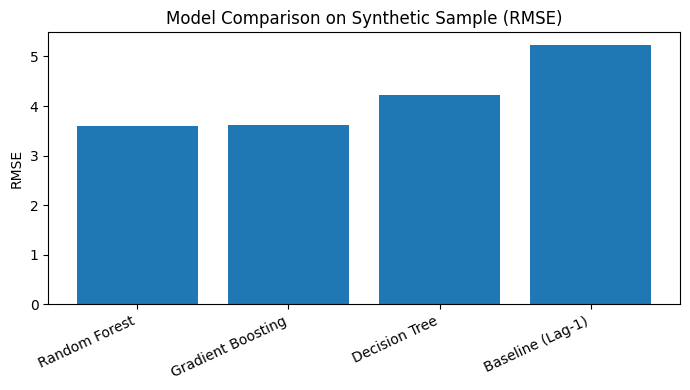

In [5]:
plt.figure(figsize=(7,4))
plt.bar(results['Model'], results['RMSE'])
plt.title('Model Comparison on Synthetic Sample (RMSE)')
plt.ylabel('RMSE')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 4. Actual vs. predicted example

This visual checks how the strongest synthetic-sample model tracks observed demand for one high-volume item in the holdout period.

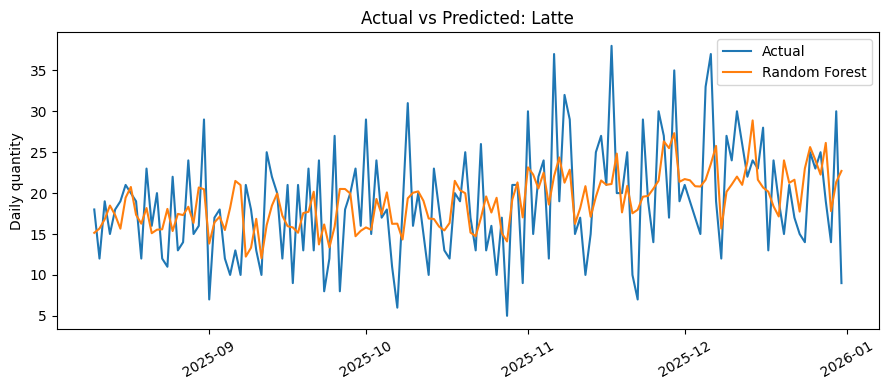

In [6]:
best_ml_name = results.loc[~results['Model'].str.startswith('Baseline'), 'Model'].iloc[0]
best_model = models[best_ml_name]
demo_item = test_df.groupby('Menu Item Final')['y'].sum().sort_values(ascending=False).index[0]
plot_df = test_df[test_df['Menu Item Final'] == demo_item].sort_values('date').copy()
plot_df['prediction'] = best_model.predict(plot_df[FEATURES])

plt.figure(figsize=(9,4))
plt.plot(plot_df['date'], plot_df['y'], label='Actual')
plt.plot(plot_df['date'], plot_df['prediction'], label=best_ml_name)
plt.title(f'Actual vs Predicted: {demo_item}')
plt.ylabel('Daily quantity')
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

## 5. One-day-ahead forecast helper

The original class demo allowed arbitrary future dates while using lag features derived from historical data. For the portfolio version, the helper is intentionally constrained to **one day ahead**. That makes the feature construction explicit and avoids presenting unknown future lag values as if they were observed.

In [7]:
item = sorted(model_df['Menu Item Final'].unique())[0]
next_day = model_df.loc[model_df['Menu Item Final'] == item, 'date'].max() + pd.Timedelta(days=1)
X_next = build_next_day_feature_row(model_df, item, next_day)
pred = max(0, best_model.predict(X_next)[0])
print(f"Item: {item}")
print(f"Forecast date: {next_day.date()}")
print(f"Predicted quantity: {pred:.1f}")

Item: Beef Pastry
Forecast date: 2026-01-01
Predicted quantity: 8.2


## Original academic results

On the original private 2024-2025 POS dataset, the completed project reported **Gradient Boosting MAE = 4.00 and RMSE = 6.98**, the best RMSE among the compared models. The original data is not distributed in this repository. Results shown by the executable cells above are based on the synthetic public sample and will differ.